## About Dataset
Context
This is a small subset of dataset of Book reviews from Amazon Kindle Store category.

Content
5-core dataset of product reviews from Amazon Kindle Store category from May 1996 - July 2014. Contains total of 982619 entries. Each reviewer has at least 5 reviews and each product has at least 5 reviews in this dataset.
Columns

- asin - ID of the product, like B000FA64PK
- helpful - helpfulness rating of the review - example: 2/3.
- overall - rating of the product.
- reviewText - text of the review (heading).
- reviewTime - time of the review (raw).
- reviewerID - ID of the reviewer, like A3SPTOKDG7WBLN
- reviewerName - name of the reviewer.
- summary - summary of the review (description).
- unixReviewTime - unix timestamp.

Acknowledgements
This dataset is taken from Amazon product data, Julian McAuley, UCSD website. http://jmcauley.ucsd.edu/data/amazon/

License to the data files belong to them.

Inspiration
- Sentiment analysis on reviews.
- Understanding how people rate usefulness of a review/ What factors influence helpfulness of a review.
- Fake reviews/ outliers.
- Best rated product IDs, or similarity between products based on reviews alone (not the best idea ikr).
- Any other interesting analysis

#### Best Practises
1. Preprocessing And Cleaning
2. Train Test Split
3. BOW,TFIDF,Word2vec
4. Train ML algorithms

### Step 1 : Load the dataset

In [1]:
import pandas as pd
df=pd.read_csv('Data/all_kindle_review.csv')
df.head()

,Unnamed: 0.1,Unnamed: 0,asin,helpful,rating,reviewText,reviewTime,reviewerID,reviewerName,summary,unixReviewTime
0,0,11539,B0033UV8HI,"[8, 10]",3,"Jace Rankin may be short, but he's nothing to ...","09 2, 2010",A3HHXRELK8BHQG,Ridley,Entertaining But Average,1283385600
1,1,5957,B002HJV4DE,"[1, 1]",5,Great short read. I didn't want to put it dow...,"10 8, 2013",A2RGNZ0TRF578I,Holly Butler,Terrific menage scenes!,1381190400
2,2,9146,B002ZG96I4,"[0, 0]",3,I'll start by saying this is the first of four...,"04 11, 2014",A3S0H2HV6U1I7F,Merissa,Snapdragon Alley,1397174400
3,3,7038,B002QHWOEU,"[1, 3]",3,Aggie is Angela Lansbury who carries pocketboo...,"07 5, 2014",AC4OQW3GZ919J,Cleargrace,very light murder cozy,1404518400
4,4,1776,B001A06VJ8,"[0, 1]",4,I did not expect this type of book to be in li...,"12 31, 2012",A3C9V987IQHOQD,Rjostler,Book,1356912000


In [4]:
df['reviewTime'].value_counts()

reviewTime
02 18, 2013    37
09 6, 2012     32
01 6, 2013     26
05 4, 2013     26
12 5, 2012     25
               ..
10 21, 2009     1
01 25, 2010     1
02 16, 2008     1
08 28, 2009     1
01 24, 2010     1
Name: count, Length: 1953, dtype: int64

In [5]:
df = df[['reviewText','rating']]
df.head()

,reviewText,rating
0,"Jace Rankin may be short, but he's nothing to ...",3
1,Great short read. I didn't want to put it dow...,5
2,I'll start by saying this is the first of four...,3
3,Aggie is Angela Lansbury who carries pocketboo...,3
4,I did not expect this type of book to be in li...,4


### Step 2 :- Data Overview 

In [6]:
df.shape

(12000, 2)

#### Check For Missing Values

In [7]:
df.isna().sum()

reviewText    0
rating        0
dtype: int64

In [8]:
df['rating'].unique()

array([3, 5, 4, 2, 1])

In [9]:
df['rating'].value_counts()

rating
5    3000
4    3000
3    2000
2    2000
1    2000
Name: count, dtype: int64

### Step 3 :- Preprocessing And Cleaning

In [10]:
import warnings
warnings.filterwarnings('ignore')

In [11]:
df['rating']=df['rating'].apply(lambda x:0 if x<3 else 1)

In [12]:
df['rating'].value_counts()

rating
1    8000
0    4000
Name: count, dtype: int64

### Lowering reviews into lowercase

In [13]:
df['reviewText'] = df['reviewText'].str.lower()

In [14]:
import re
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
from bs4 import BeautifulSoup

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


#### i) Removing special characters

In [15]:
df['reviewText'] = df['reviewText'].apply(lambda x:re.sub('[^a-z A-z 0-9]+', '',x))

In [16]:
df['reviewText'][0]

'jace rankin may be short but hes nothing to mess with as the man who was just hauled out of the saloon by the undertaker knows now hes a famous bounty hunter in oregon in the 1890s who when he shot the man in the saloon just finished a years long quest to avenge his sisters murder and is now trying to figure out what to do next when the snottynosed farm boy he just rescued from a gang of bullies offers him money to kill a man who forced him off his ranch he reluctantly agrees to bring the man to justice but not to kill him outright but first he needs to tell his sisters widower the newskyla kyle springer bailey has been riding the trails and sleeping on the ground for the past month while trying to find jace she wants revenge on the man who killed her husband and took her ranch amongst other crimes and shes not so keen on the detour jace wants to take but she realizes shes out of options so she hides behind her boy persona as best she can and tries to keep pace when a confrontation al

#### ii) Remove the stopswords


In [19]:
df['reviewText']=df['reviewText'].apply(lambda x:" ".join([y for y in x.split() if y not in stopwords.words('english')]))

In [20]:
df['reviewText']

0        jace rankin may short hes nothing mess man hau...
1        great short read didnt want put read one sitti...
2        ill start saying first four books wasnt expect...
3        aggie angela lansbury carries pocketbooks inst...
4        expect type book library pleased find price right
                               ...                        
11995    valentine cupid vampire jena ian another vampi...
11996    read seven books series apocalypticadventure o...
11997    book really wasnt cuppa situation man capturin...
11998    tried use charge kindle didnt even register ch...
11999    taking instruction look often hidden world sex...
Name: reviewText, Length: 12000, dtype: object

In [21]:
df['reviewText']

0        jace rankin may short hes nothing mess man hau...
1        great short read didnt want put read one sitti...
2        ill start saying first four books wasnt expect...
3        aggie angela lansbury carries pocketbooks inst...
4        expect type book library pleased find price right
                               ...                        
11995    valentine cupid vampire jena ian another vampi...
11996    read seven books series apocalypticadventure o...
11997    book really wasnt cuppa situation man capturin...
11998    tried use charge kindle didnt even register ch...
11999    taking instruction look often hidden world sex...
Name: reviewText, Length: 12000, dtype: object

#### iii) Remove url 

In [22]:
df['reviewText']=df['reviewText'].apply(lambda x: re.sub(r'(http|https|ftp|ssh)://([\w_-]+(?:(?:\.[\w_-]+)+))([\w.,@?^=%&:/~+#-]*[\w@?^=%&/~+#-])?', '' , str(x)))

#### iv) Remove html tags

In [23]:
df['reviewText']=df['reviewText'].apply(lambda x: BeautifulSoup(x, 'lxml').get_text())

#### v) Remove any additional spaces

In [24]:
df['reviewText']=df['reviewText'].apply(lambda x: " ".join(x.split()))

### Steamming
- For Removing {ing,s,ed,ly}

In [25]:
## Lemmatizer
from nltk.stem import WordNetLemmatizer
lemmatizer=WordNetLemmatizer()

In [26]:
def lemmatize_words(text):
    return " ".join([lemmatizer.lemmatize(word) for word in text.split()])

In [27]:
df['reviewText']=df['reviewText'].apply(lambda x:lemmatize_words(x))

--- 
# Data Cleaned
---

### Step 4 :- Train Test Split

In [28]:
## Train Test Split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(df['reviewText'],df['rating'],test_size=0.20)

In [29]:
X_train.shape , y_train.shape

((9600,), (9600,))

In [30]:
X_test.shape , y_test.shape

((2400,), (2400,))

### Step 5 :- Chaning Words to Vectors 

#### i) Using BOW(Bag of Words)

In [31]:
from sklearn.feature_extraction.text import CountVectorizer
bow=CountVectorizer()

In [32]:
X_train_bow=bow.fit_transform(X_train).toarray()
X_test_bow=bow.transform(X_test).toarray()

### ii) Using TFIDF(term frequency-inverse document frequency)

In [33]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf=TfidfVectorizer()

In [34]:
X_train_tfidf=tfidf.fit_transform(X_train).toarray()
X_test_tfidf=tfidf.transform(X_test).toarray()

---

### Step 6 :- Buliding ML Model

**`1. Import the Model`**

In [35]:
from sklearn.naive_bayes import GaussianNB

nb_model_bow = GaussianNB()
nb_model_tfidf = GaussianNB()

**`2. Train the Model`**

- `BOW Model Train`

In [36]:
nb_model_bow.fit(X_train_bow,y_train)

GaussianNB()

- `Tfidf Model Train`

In [37]:
nb_model_tfidf.fit(X_train_tfidf,y_train)

GaussianNB()

### Step 7 :- Predict the Model

**`i) Predict model of bow Vectors`**

In [38]:
y_pred_bow=nb_model_bow.predict(X_test_bow)
y_pred_bow

array([0, 1, 1, ..., 0, 0, 0])

**`ii) Predict model of Tfidf Vectors`**

In [39]:
y_pred_tfidf=nb_model_bow.predict(X_test_tfidf)
y_pred_tfidf

array([0, 1, 1, ..., 0, 0, 0])

### Step :- 8 Evaluate 

In [40]:
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report

**`i) Confusion Matrix`**
- BOW

In [41]:
confusion_matrix(y_test,y_pred_bow)

array([[528, 283],
       [734, 855]])

In [44]:
(522 + 840)/(2400)

0.5675

In [44]:
print(classification_report(y_test,y_pred_bow))

              precision    recall  f1-score   support

           0       0.42      0.65      0.51       811
           1       0.75      0.54      0.63      1589

    accuracy                           0.58      2400
   macro avg       0.58      0.59      0.57      2400
weighted avg       0.64      0.58      0.59      2400



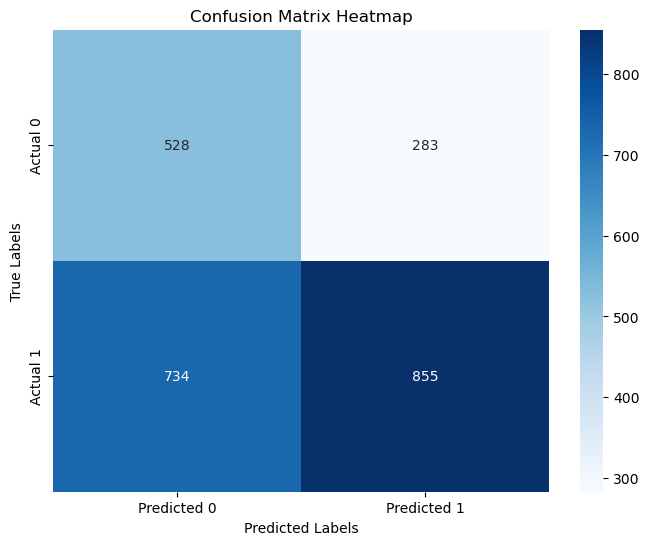

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Assuming y_test and y_pred_bow are defined
# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred_bow)

# Create a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])

# Add labels and title
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix Heatmap')
plt.show()

- TFIDF

In [45]:
confusion_matrix(y_test,y_pred_tfidf)

array([[519, 292],
       [729, 860]])

In [47]:
print(classification_report(y_test,y_pred_tfidf))

              precision    recall  f1-score   support

           0       0.42      0.64      0.50       811
           1       0.75      0.54      0.63      1589

    accuracy                           0.57      2400
   macro avg       0.58      0.59      0.57      2400
weighted avg       0.63      0.57      0.59      2400



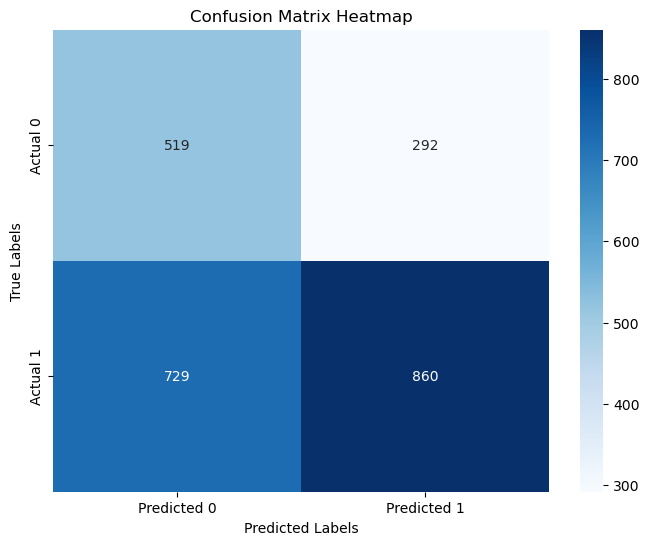

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Assuming y_test and y_pred_bow are defined
# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred_tfidf)

# Create a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])

# Add labels and title
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix Heatmap')
plt.show()

**`ii) Accuracy of Model`**
- BOW

In [48]:
print("BOW accuracy: ",accuracy_score(y_test,y_pred_bow))

BOW accuracy:  0.57625


- TFIDF

In [49]:
print("TFIDF accuracy: ",accuracy_score(y_test,y_pred_tfidf))

TFIDF accuracy:  0.5745833333333333


In [52]:
df['reviewText'][11999]

'taking instruction look often hidden world sexual bdsm pretty good job telling story get sense craigs jessicas personality werent really welldeveloped characterization seemed overwhelmed explicit sex scene composed story wonder craig got money custommade dungeon built much traveling professor salary since know personal experience poorly academic paid overall since find scene erotic would recommend book'

In [54]:
nb_model_tfidf.predict(tfidf.transform([df['reviewText'][0]]).toarray())

array([1])

In [55]:
y_train[0]

np.int64(1)